#### Exercise 13 - Starter - Estimate Regression Discontinuity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.formula.api as smf


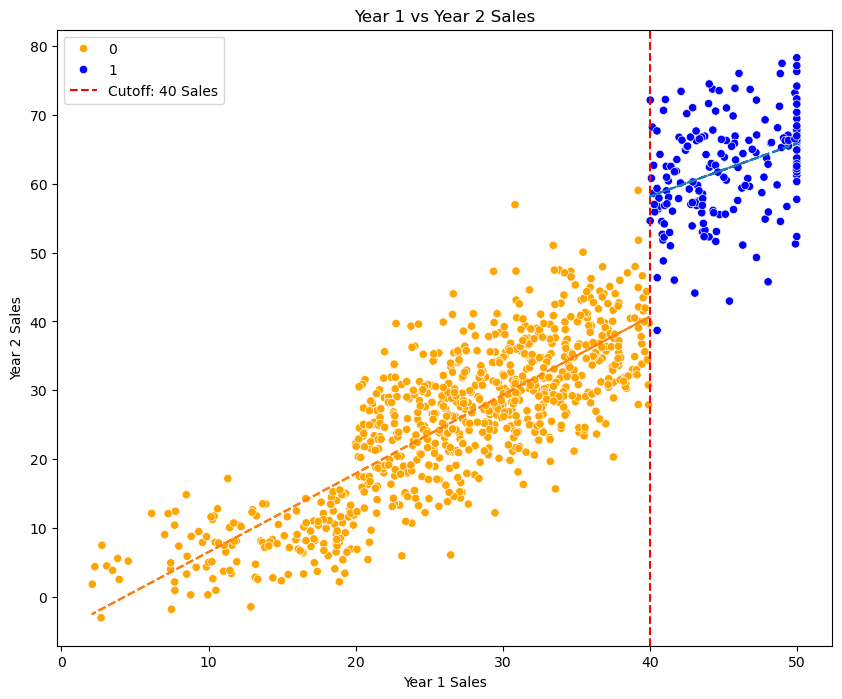

In [10]:
# TO-DO: Read in employee sales data from: rd_employee_sales_data.csv
df=pd.read_csv('https://raw.githubusercontent.com/udacity/causal-inference-foundations/refs/heads/main/Exercise13-regression-discontinuity/data/rd_employee_sales_data.csv')

# df.head()
# set parameters: 40 is the cuttoff for the sales training 
cutoff = 40

# TO-DO: Visualize the discontinuity. 
# Create a scatterplot of Year 1 Sales vs Year 2 Sales, colored by Training status
# Bonus: Add linear slope fits for each value of Training

plt.figure(figsize=(10, 8))
sns.scatterplot(df, x='Year1_Sales', y='Year2_Sales', hue='Training',palette={1: "blue", 0: "orange"})
plt.axvline(cutoff, label='Cutoff: 40 Sales', linestyle='--', color='r')

for i in df['Training'].unique():
    subset=df[df['Training']==i]
    result = stats.linregress(subset['Year1_Sales'], subset['Year2_Sales'])
    fitted_line = result.slope*subset['Year1_Sales']+result.intercept
    plt.plot(subset['Year1_Sales'], fitted_line, linestyle='--')
    
plt.legend(loc='upper left')
plt.xlabel('Year 1 Sales')
plt.ylabel('Year 2 Sales')
plt.title('Year 1 vs Year 2 Sales')
plt.show()

In [11]:
# TO-DO: Estimate the RD model using all data while excluding Year 1 Sales as the predictor 
formula = 'Year2_Sales ~ Training'

model=smf.ols(formula=formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.643
Model:                            OLS   Adj. R-squared:                  0.643
Method:                 Least Squares   F-statistic:                     1797.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):          1.96e-225
Time:                        14:34:23   Log-Likelihood:                -3783.7
No. Observations:                1000   AIC:                             7571.
Df Residuals:                     998   BIC:                             7581.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.7360      0.374     68.849      0.0

**Observation:**

We started by modeling Year2_Sales ~ Training, which produced a coefficient of 36.5494. This dramatically overstated the effect, which we know has a ground truth of 20. The issue with this model was that it didn't account for the underlying skill that led these users to get the training—a confounding variable that wasn't represented in this model.

In [12]:
# TO-DO: Estimate the RD model using all data while including the running variable (Year 1 Sales) as a predictor 
# How does this change the estimated effect of Training on Year 2 Sales?

df['RunningVar']=df['Year1_Sales']-cutoff
formula = 'Year2_Sales ~ Training+RunningVar'

model=smf.ols(formula=formula, data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.861
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     3084.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        14:35:08   Log-Likelihood:                -3312.5
No. Observations:                1000   AIC:                             6631.
Df Residuals:                     997   BIC:                             6646.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     40.4997      0.441     91.915      0.0

**Observation**

Then, we added in the variable for Year 1 sales, which is a proxy for the underlying skill. So we had a formula of Year2_Sales ~ Training + Year1_Sales. Our resulting coefficient was 15.7377, which was closer to the ground truth. However, the issue was that we included the entire spectrum of employees, not just those who were close to the cutoff.

In [13]:
# TO-DO: Re-estimate the RD model using only users with Year 1 Sales within 10 of the cutoff 
# How does this change the estimated effect of Training on Year 2 Sales?

bandwidth=10
# df['treated']=(df['RunningVar']>=0).astype(int)
subset_10=df[(df['RunningVar']>=-bandwidth)&(df['RunningVar']<=bandwidth)]
formula = 'Year2_Sales ~ RunningVar+Training'

model=smf.ols(formula=formula, data=subset_10).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     1131.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):          2.51e-189
Time:                        14:35:39   Log-Likelihood:                -1717.0
No. Observations:                 519   AIC:                             3440.
Df Residuals:                     516   BIC:                             3453.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.6570      0.654     59.077      0.0

**Observation:**

This time, we ran the same formula Year2_Sales ~ Training + Year1_Sales but using only a subset of employees. Specifically, we only included employees at the cutoff plus or minus 10. We got a coefficient of 19.1818, and the ground truth was within the 95% CI of (16.788, 21.576).

In [16]:
# What's the effect of training on Year 2 Sales at the cutoff, relative to Expected Year 2 Sales without training?

trained = subset_10[subset_10['Training'] == 1].copy()
trained['predicted_year2_sales'] = model.predict(trained)
trained['baseline_year2_sales'] = trained['Year2_Sales'] - model.params['Training'] 
relative_effect = model.params['Training'] / trained['baseline_year2_sales'].mean()
print(f"Relative effect of training on Year 2 Sales at the cutoff: {100*relative_effect:.1f}%")

Relative effect of training on Year 2 Sales at the cutoff: 44.5%


In [17]:
# TO-DO: Re-estimate the RD model using only users with Year 1 Sales within 5 of the cutoff
# How does this change the estimated effect of Training on Year 2 Sales?  Are results sensitive to the bandwidth?

bandwidth=5
subset_5=df[(df['RunningVar']>=-bandwidth)&(df['RunningVar']<=bandwidth)]
formula = 'Year2_Sales ~ RunningVar+Training'

model=smf.ols(formula=formula, data=subset_5).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Year2_Sales   R-squared:                       0.754
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     344.1
Date:                Mon, 08 Dec 2025   Prob (F-statistic):           4.94e-69
Time:                        14:38:28   Log-Likelihood:                -751.49
No. Observations:                 227   AIC:                             1509.
Df Residuals:                     224   BIC:                             1519.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     38.8253      1.015     38.260      0.0

In [18]:
trained = subset_5[subset_5['Training'] == 1].copy()
trained['predicted_year2_sales'] = model.predict(trained)
trained['baseline_year2_sales'] = trained['Year2_Sales'] - model.params['Training'] 
relative_effect = model.params['Training'] / trained['baseline_year2_sales'].mean()
print(f"Relative effect of training on Year 2 Sales at the cutoff: {100*relative_effect:.1f}%")

Relative effect of training on Year 2 Sales at the cutoff: 47.2%


**Observation**

Finally, we repeated the same formula using only employees at the cutoff plus or minus 5. Our resulting coefficient was 19.2648, and again, the ground truth was within the 95% CI of (15.679, 22.850).